# Census Data Analysis


# Objective:

The following will be used as preliminary data analysis, cleaning, prep and statistical analysis. This will aid us in feature generation and model selection

Our Key focuses are:
- Data structure and types
- Missing / unknown values
- Target variable distribution
- Feature relationships
- Initial hypotheses for modeling

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_selection import mutual_info_classif


# Display settings for readability
pd.set_option('display.max_columns', 100)
sns.set_style('whitegrid')

In [ ]:
# Load training dataset
train_df = pd.read_csv('../data/raw/census_income_learn.csv',header=None)


# Load metadata 
with open('../data/raw/census_income_metadata.txt', 'r') as file:
    metadata = file.read()

print("Training data shape:", train_df.shape)
train_df.head(1)

Training data shape: (199523, 42)


,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,31,32,33,34,35,36,37,38,39,40,41
0,73,Not in universe,0,0,High school graduate,0,Not in universe,Widowed,Not in universe or children,Not in universe,White,All other,Female,Not in universe,Not in universe,Not in labor force,0,0,0,Nonfiler,Not in universe,Not in universe,Other Rel 18+ ever marr not in subfamily,Other relative of householder,1700.09,?,?,?,Not in universe under 1 year old,?,0,Not in universe,United-States,United-States,United-States,Native- Born in the United States,0,Not in universe,2,0,95,- 50000.


In [ ]:
# The metadata file contains a mapping of feature names to internal census codes.

lines = metadata.split("\n")
columns = []
capture = False

for line in lines:
    line = line.strip()
    
    # Start capturing from the first actual column
    if line.startswith("| age"):
        capture = True
    
    # Stop when we reach the stats section
    if line.startswith("| Basic statistics"):
        break
    
    if not capture:
        continue
    
    if line.startswith("|"):
        line = line.replace("|", "").strip()
        parts = line.split()
        
        # last value is internal code, rest is name
        if len(parts) > 1:
            name = " ".join(parts[:-1])
            columns.append(name)

print("Number of columns in data set:",len(columns))


comparing the data from the training set we will now try to identify what columns are missing from the data sets as there is a miss match of 45 in metadata to 42 in learn and test. 

In [4]:
# missing fields from list: 
# adjusted gross income
# federal income tax liability
# taxable income amount
# total person income

# misisng from meta data"
# year 
# income target variable 



# last column is target column meaning we have 41 in data set, 45 in meta data ... 45-41 = 4 missing columns in data plus the year column makes 5 we have to identify


missing_columns = [
    "adjusted gross income",
    "federal income tax liability",
    "total person earnings",
    "total person income",
    "taxable income amount",
]

columns = [col for col in columns if col not in missing_columns]

# Fix spelling mistake
columns = ["race" if col == "mace" else col for col in columns]

# Add missing column from meta data that is in the data set
columns.append("year")

print(len(columns))        # should be 41
print(train_df.shape[1])         # should be 42

train_df.columns = columns + ["income"]

# we can here visually see that the columns and names are aligned correctly
train_df.head(5)


41
42


,age,class of worker,industry code,occupation code,education,wage per hour,enrolled in edu inst last wk,marital status,major industry code,major occupation code,race,hispanic Origin,sex,member of a labor union,reason for unemployment,full or part time employment stat,capital gains,capital losses,divdends from stocks,tax filer status,region of previous residence,state of previous residence,detailed household and family stat,detailed household summary in household,instance weight,migration code-change in msa,migration code-change in reg,migration code-move within reg,live in this house 1 year ago,migration prev res in sunbelt,num persons worked for employer,family members under 18,country of birth father,country of birth mother,country of birth self,citizenship,own business or self employed,fill inc questionnaire for veteran's admin,veterans benefits,weeks worked in year,year,income
0,73,Not in universe,0,0,High school graduate,0,Not in universe,Widowed,Not in universe or children,Not in universe,White,All other,Female,Not in universe,Not in universe,Not in labor force,0,0,0,Nonfiler,Not in universe,Not in universe,Other Rel 18+ ever marr not in subfamily,Other relative of householder,1700.09,?,?,?,Not in universe under 1 year old,?,0,Not in universe,United-States,United-States,United-States,Native- Born in the United States,0,Not in universe,2,0,95,- 50000.
1,58,Self-employed-not incorporated,4,34,Some college but no degree,0,Not in universe,Divorced,Construction,Precision production craft & repair,White,All other,Male,Not in universe,Not in universe,Children or Armed Forces,0,0,0,Head of household,South,Arkansas,Householder,Householder,1053.55,MSA to MSA,Same county,Same county,No,Yes,1,Not in universe,United-States,United-States,United-States,Native- Born in the United States,0,Not in universe,2,52,94,- 50000.
2,18,Not in universe,0,0,10th grade,0,High school,Never married,Not in universe or children,Not in universe,Asian or Pacific Islander,All other,Female,Not in universe,Not in universe,Not in labor force,0,0,0,Nonfiler,Not in universe,Not in universe,Child 18+ never marr Not in a subfamily,Child 18 or older,991.95,?,?,?,Not in universe under 1 year old,?,0,Not in universe,Vietnam,Vietnam,Vietnam,Foreign born- Not a citizen of U S,0,Not in universe,2,0,95,- 50000.
3,9,Not in universe,0,0,Children,0,Not in universe,Never married,Not in universe or children,Not in universe,White,All other,Female,Not in universe,Not in universe,Children or Armed Forces,0,0,0,Nonfiler,Not in universe,Not in universe,Child <18 never marr not in subfamily,Child under 18 never married,1758.14,Nonmover,Nonmover,Nonmover,Yes,Not in universe,0,Both parents present,United-States,United-States,United-States,Native- Born in the United States,0,Not in universe,0,0,94,- 50000.
4,10,Not in universe,0,0,Children,0,Not in universe,Never married,Not in universe or children,Not in universe,White,All other,Female,Not in universe,Not in universe,Children or Armed Forces,0,0,0,Nonfiler,Not in universe,Not in universe,Child <18 never marr not in subfamily,Child under 18 never married,1069.16,Nonmover,Nonmover,Nonmover,Yes,Not in universe,0,Both parents present,United-States,United-States,United-States,Native- Born in the United States,0,Not in universe,0,0,94,- 50000.


#### The following is the data cleaning and DQ checks

In [5]:
train_df.shape


(199523, 42)

In [6]:
train_df.info()


<class 'pandas.DataFrame'>
RangeIndex: 199523 entries, 0 to 199522
Data columns (total 42 columns):
 #   Column                                      Non-Null Count   Dtype  
---  ------                                      --------------   -----  
 0   age                                         199523 non-null  int64  
 1   class of worker                             199523 non-null  str    
 2   industry code                               199523 non-null  int64  
 3   occupation code                             199523 non-null  int64  
 4   education                                   199523 non-null  str    
 5   wage per hour                               199523 non-null  int64  
 6   enrolled in edu inst last wk                199523 non-null  str    
 7   marital status                              199523 non-null  str    
 8   major industry code                         199523 non-null  str    
 9   major occupation code                       199523 non-null  str    
 10  race   

In [7]:
# no actual Nulls in the data set, meaning the data contains place holders for nulls 
train_df.isnull().sum().sort_values(ascending=False)


age                                           0
class of worker                               0
industry code                                 0
occupation code                               0
education                                     0
wage per hour                                 0
enrolled in edu inst last wk                  0
marital status                                0
major industry code                           0
major occupation code                         0
race                                          0
hispanic Origin                               0
sex                                           0
member of a labor union                       0
reason for unemployment                       0
full or part time employment stat             0
capital gains                                 0
capital losses                                0
divdends from stocks                          0
tax filer status                              0
region of previous residence            

In [8]:
#  Here i am checking uniqueness of each column to beter understand them and what they contain

for col in train_df.columns:
    print(f"\nColumn: {col}")
    print(f"Unique count: {train_df[col].nunique()}")
    print(train_df[col].value_counts())


Column: age
Unique count: 91
age
34    3489
35    3450
36    3353
31    3351
33    3340
      ... 
85     423
86     348
87     301
88     241
89     195
Name: count, Length: 91, dtype: int64

Column: class of worker
Unique count: 9
class of worker
Not in universe                   100245
Private                            72028
Self-employed-not incorporated      8445
Local government                    7784
State government                    4227
Self-employed-incorporated          3265
Federal government                  2925
Never worked                         439
Without pay                          165
Name: count, dtype: int64

Column: industry code
Unique count: 52
industry code
0     100684
33     17070
43      8283
4       5984
42      4683
45      4482
29      4209
37      4022
41      3964
32      3596
35      3380
39      2937
34      2765
44      2549
2       2196
11      1764
50      1704
40      1651
47      1644
38      1629
24      1503
12      1350
19      1346
30

In [9]:
#  Here i am using a regex to remove the ? from that data which was likely used by the surveryor as a null value ( or when the person being questioned didnt know / didnt aply to them)

train_df = train_df.apply(lambda col: col.str.strip() if col.dtype == "object" else col)
train_df.replace(r'^\s*\?\s*$', np.nan, regex=True, inplace=True)
train_df.head(3)

,age,class of worker,industry code,occupation code,education,wage per hour,enrolled in edu inst last wk,marital status,major industry code,major occupation code,race,hispanic Origin,sex,member of a labor union,reason for unemployment,full or part time employment stat,capital gains,capital losses,divdends from stocks,tax filer status,region of previous residence,state of previous residence,detailed household and family stat,detailed household summary in household,instance weight,migration code-change in msa,migration code-change in reg,migration code-move within reg,live in this house 1 year ago,migration prev res in sunbelt,num persons worked for employer,family members under 18,country of birth father,country of birth mother,country of birth self,citizenship,own business or self employed,fill inc questionnaire for veteran's admin,veterans benefits,weeks worked in year,year,income
0,73,Not in universe,0,0,High school graduate,0,Not in universe,Widowed,Not in universe or children,Not in universe,White,All other,Female,Not in universe,Not in universe,Not in labor force,0,0,0,Nonfiler,Not in universe,Not in universe,Other Rel 18+ ever marr not in subfamily,Other relative of householder,1700.09,NaN,NaN,NaN,Not in universe under 1 year old,NaN,0,Not in universe,United-States,United-States,United-States,Native- Born in the United States,0,Not in universe,2,0,95,- 50000.
1,58,Self-employed-not incorporated,4,34,Some college but no degree,0,Not in universe,Divorced,Construction,Precision production craft & repair,White,All other,Male,Not in universe,Not in universe,Children or Armed Forces,0,0,0,Head of household,South,Arkansas,Householder,Householder,1053.55,MSA to MSA,Same county,Same county,No,Yes,1,Not in universe,United-States,United-States,United-States,Native- Born in the United States,0,Not in universe,2,52,94,- 50000.
2,18,Not in universe,0,0,10th grade,0,High school,Never married,Not in universe or children,Not in universe,Asian or Pacific Islander,All other,Female,Not in universe,Not in universe,Not in labor force,0,0,0,Nonfiler,Not in universe,Not in universe,Child 18+ never marr Not in a subfamily,Child 18 or older,991.95,NaN,NaN,NaN,Not in universe under 1 year old,NaN,0,Not in universe,Vietnam,Vietnam,Vietnam,Foreign born- Not a citizen of U S,0,Not in universe,2,0,95,- 50000.


In [10]:
# The value counts shows me which columns have highly incomplete data

train_df.isnull().sum().sort_values(ascending=False)

migration prev res in sunbelt                 99696
migration code-change in msa                  99696
migration code-change in reg                  99696
migration code-move within reg                99696
country of birth father                        6713
country of birth mother                        6119
country of birth self                          3393
state of previous residence                     708
age                                               0
class of worker                                   0
major occupation code                             0
major industry code                               0
marital status                                    0
enrolled in edu inst last wk                      0
wage per hour                                     0
education                                         0
occupation code                                   0
industry code                                     0
capital losses                                    0
capital gain

In [11]:
(train_df == "?").sum().sum()  # should be 0

np.int64(0)

In [12]:
# final NaN checks
train_df.replace("?", np.nan, inplace=True)
train_df.head(3)

,age,class of worker,industry code,occupation code,education,wage per hour,enrolled in edu inst last wk,marital status,major industry code,major occupation code,race,hispanic Origin,sex,member of a labor union,reason for unemployment,full or part time employment stat,capital gains,capital losses,divdends from stocks,tax filer status,region of previous residence,state of previous residence,detailed household and family stat,detailed household summary in household,instance weight,migration code-change in msa,migration code-change in reg,migration code-move within reg,live in this house 1 year ago,migration prev res in sunbelt,num persons worked for employer,family members under 18,country of birth father,country of birth mother,country of birth self,citizenship,own business or self employed,fill inc questionnaire for veteran's admin,veterans benefits,weeks worked in year,year,income
0,73,Not in universe,0,0,High school graduate,0,Not in universe,Widowed,Not in universe or children,Not in universe,White,All other,Female,Not in universe,Not in universe,Not in labor force,0,0,0,Nonfiler,Not in universe,Not in universe,Other Rel 18+ ever marr not in subfamily,Other relative of householder,1700.09,NaN,NaN,NaN,Not in universe under 1 year old,NaN,0,Not in universe,United-States,United-States,United-States,Native- Born in the United States,0,Not in universe,2,0,95,- 50000.
1,58,Self-employed-not incorporated,4,34,Some college but no degree,0,Not in universe,Divorced,Construction,Precision production craft & repair,White,All other,Male,Not in universe,Not in universe,Children or Armed Forces,0,0,0,Head of household,South,Arkansas,Householder,Householder,1053.55,MSA to MSA,Same county,Same county,No,Yes,1,Not in universe,United-States,United-States,United-States,Native- Born in the United States,0,Not in universe,2,52,94,- 50000.
2,18,Not in universe,0,0,10th grade,0,High school,Never married,Not in universe or children,Not in universe,Asian or Pacific Islander,All other,Female,Not in universe,Not in universe,Not in labor force,0,0,0,Nonfiler,Not in universe,Not in universe,Child 18+ never marr Not in a subfamily,Child 18 or older,991.95,NaN,NaN,NaN,Not in universe under 1 year old,NaN,0,Not in universe,Vietnam,Vietnam,Vietnam,Foreign born- Not a citizen of U S,0,Not in universe,2,0,95,- 50000.


In [13]:
# Here i can clearly see that the migration codes are almost 50% missing data which can impact model performance later on
missing = train_df.isnull().sum()
missing_pct = (missing / len(train_df)) * 100

missing_df = pd.DataFrame({
    "missing_count": missing,
    "missing_pct": missing_pct
}).sort_values(by="missing_pct", ascending=False)

missing_df.head(20)

,missing_count,missing_pct
migration prev res in sunbelt,99696,49.967172
migration code-change in msa,99696,49.967172
migration code-change in reg,99696,49.967172
migration code-move within reg,99696,49.967172
country of birth father,6713,3.364524
country of birth mother,6119,3.066814
country of birth self,3393,1.700556
state of previous residence,708,0.354846
age,0,0.000000
class of worker,0,0.000000


In [14]:
# Columns with a high ammount of nans related to migration patterns were removed due to low data completeness

cols_to_drop = [
    "migration prev res in sunbelt",
    "migration code-change in msa",
    "migration code-change in reg",
    "migration code-move within reg"
]

train_df.drop(columns=cols_to_drop, inplace=True)

In [15]:
# categorical columns we will use a unknown flag as included in the additional data pdf supplied  
 
cat_fill_cols = [
    "country of birth father",
    "country of birth mother",
    "state of previous residence",
    "country of birth self"
]

for col in cat_fill_cols:
    train_df[col] = train_df[col].fillna("Unknown")

In [16]:
train_df.head(3)

,age,class of worker,industry code,occupation code,education,wage per hour,enrolled in edu inst last wk,marital status,major industry code,major occupation code,race,hispanic Origin,sex,member of a labor union,reason for unemployment,full or part time employment stat,capital gains,capital losses,divdends from stocks,tax filer status,region of previous residence,state of previous residence,detailed household and family stat,detailed household summary in household,instance weight,live in this house 1 year ago,num persons worked for employer,family members under 18,country of birth father,country of birth mother,country of birth self,citizenship,own business or self employed,fill inc questionnaire for veteran's admin,veterans benefits,weeks worked in year,year,income
0,73,Not in universe,0,0,High school graduate,0,Not in universe,Widowed,Not in universe or children,Not in universe,White,All other,Female,Not in universe,Not in universe,Not in labor force,0,0,0,Nonfiler,Not in universe,Not in universe,Other Rel 18+ ever marr not in subfamily,Other relative of householder,1700.09,Not in universe under 1 year old,0,Not in universe,United-States,United-States,United-States,Native- Born in the United States,0,Not in universe,2,0,95,- 50000.
1,58,Self-employed-not incorporated,4,34,Some college but no degree,0,Not in universe,Divorced,Construction,Precision production craft & repair,White,All other,Male,Not in universe,Not in universe,Children or Armed Forces,0,0,0,Head of household,South,Arkansas,Householder,Householder,1053.55,No,1,Not in universe,United-States,United-States,United-States,Native- Born in the United States,0,Not in universe,2,52,94,- 50000.
2,18,Not in universe,0,0,10th grade,0,High school,Never married,Not in universe or children,Not in universe,Asian or Pacific Islander,All other,Female,Not in universe,Not in universe,Not in labor force,0,0,0,Nonfiler,Not in universe,Not in universe,Child 18+ never marr Not in a subfamily,Child 18 or older,991.95,Not in universe under 1 year old,0,Not in universe,Vietnam,Vietnam,Vietnam,Foreign born- Not a citizen of U S,0,Not in universe,2,0,95,- 50000.


In [17]:
# Recheck success of nan replacements with null values
missing = train_df.isnull().sum()
missing_pct = (missing / len(train_df)) * 100

missing_df = pd.DataFrame({
    "missing_count": missing,
    "missing_pct": missing_pct
}).sort_values(by="missing_pct", ascending=False)

missing_df.head(8)

,missing_count,missing_pct
age,0,0.0
class of worker,0,0.0
industry code,0,0.0
occupation code,0,0.0
education,0,0.0
wage per hour,0,0.0
enrolled in edu inst last wk,0,0.0
marital status,0,0.0


In [18]:
train_df.duplicated().sum()


np.int64(3237)

In [19]:
# full row duplicates
dup_full = train_df.duplicated().sum()

# duplicates excluding target 
dup_features = train_df.drop(columns=['income']).duplicated().sum()

print(dup_full, dup_features)

3237 3238


In [20]:
# 1 case where the same features have to different income labels , possible duplication as only 1 row means it was probably double submitted or a mistake 

In [21]:
train_df = train_df.drop_duplicates()

In [22]:
# Comparing dupe rows with different target 

conflict = train_df[train_df.duplicated(subset=train_df.columns[:-1], keep=False)]
print(conflict) 

       age   class of worker  industry code  occupation code  \
3949    68   Not in universe              0                0   
21873   68   Not in universe              0                0   

                   education  wage per hour enrolled in edu inst last wk  \
3949    High school graduate              0              Not in universe   
21873   High school graduate              0              Not in universe   

                         marital status           major industry code  \
3949    Married-civilian spouse present   Not in universe or children   
21873   Married-civilian spouse present   Not in universe or children   

      major occupation code    race hispanic Origin      sex  \
3949        Not in universe   White       All other   Female   
21873       Not in universe   White       All other   Female   

      member of a labor union reason for unemployment  \
3949          Not in universe         Not in universe   
21873         Not in universe         Not in univer

In [23]:
# safest option since only 1 case is to drop both
train_df = train_df.drop_duplicates(subset=train_df.columns[:-1], keep=False)


In [24]:
train_df.info()

<class 'pandas.DataFrame'>
Index: 196284 entries, 0 to 199522
Data columns (total 38 columns):
 #   Column                                      Non-Null Count   Dtype  
---  ------                                      --------------   -----  
 0   age                                         196284 non-null  int64  
 1   class of worker                             196284 non-null  str    
 2   industry code                               196284 non-null  int64  
 3   occupation code                             196284 non-null  int64  
 4   education                                   196284 non-null  str    
 5   wage per hour                               196284 non-null  int64  
 6   enrolled in edu inst last wk                196284 non-null  str    
 7   marital status                              196284 non-null  str    
 8   major industry code                         196284 non-null  str    
 9   major occupation code                       196284 non-null  str    
 10  race        

## Initial Analysis

In [25]:

print("Shape:", train_df.shape)

print("\nInfo:")
train_df.info()


Shape: (196284, 38)

Info:
<class 'pandas.DataFrame'>
Index: 196284 entries, 0 to 199522
Data columns (total 38 columns):
 #   Column                                      Non-Null Count   Dtype  
---  ------                                      --------------   -----  
 0   age                                         196284 non-null  int64  
 1   class of worker                             196284 non-null  str    
 2   industry code                               196284 non-null  int64  
 3   occupation code                             196284 non-null  int64  
 4   education                                   196284 non-null  str    
 5   wage per hour                               196284 non-null  int64  
 6   enrolled in edu inst last wk                196284 non-null  str    
 7   marital status                              196284 non-null  str    
 8   major industry code                         196284 non-null  str    
 9   major occupation code                       196284 non-null

In [26]:
train_df.head(3)


,age,class of worker,industry code,occupation code,education,wage per hour,enrolled in edu inst last wk,marital status,major industry code,major occupation code,race,hispanic Origin,sex,member of a labor union,reason for unemployment,full or part time employment stat,capital gains,capital losses,divdends from stocks,tax filer status,region of previous residence,state of previous residence,detailed household and family stat,detailed household summary in household,instance weight,live in this house 1 year ago,num persons worked for employer,family members under 18,country of birth father,country of birth mother,country of birth self,citizenship,own business or self employed,fill inc questionnaire for veteran's admin,veterans benefits,weeks worked in year,year,income
0,73,Not in universe,0,0,High school graduate,0,Not in universe,Widowed,Not in universe or children,Not in universe,White,All other,Female,Not in universe,Not in universe,Not in labor force,0,0,0,Nonfiler,Not in universe,Not in universe,Other Rel 18+ ever marr not in subfamily,Other relative of householder,1700.09,Not in universe under 1 year old,0,Not in universe,United-States,United-States,United-States,Native- Born in the United States,0,Not in universe,2,0,95,- 50000.
1,58,Self-employed-not incorporated,4,34,Some college but no degree,0,Not in universe,Divorced,Construction,Precision production craft & repair,White,All other,Male,Not in universe,Not in universe,Children or Armed Forces,0,0,0,Head of household,South,Arkansas,Householder,Householder,1053.55,No,1,Not in universe,United-States,United-States,United-States,Native- Born in the United States,0,Not in universe,2,52,94,- 50000.
2,18,Not in universe,0,0,10th grade,0,High school,Never married,Not in universe or children,Not in universe,Asian or Pacific Islander,All other,Female,Not in universe,Not in universe,Not in labor force,0,0,0,Nonfiler,Not in universe,Not in universe,Child 18+ never marr Not in a subfamily,Child 18 or older,991.95,Not in universe under 1 year old,0,Not in universe,Vietnam,Vietnam,Vietnam,Foreign born- Not a citizen of U S,0,Not in universe,2,0,95,- 50000.


In [27]:

# 3. Summary stats (numeric)
print("\nDescribe (numeric):")
display(train_df.describe())

# 4. Summary stats (categorical)
print("\nDescribe (categorical):")
display(train_df.describe(include=['object', 'string']))


Describe (numeric):


,age,industry code,occupation code,wage per hour,capital gains,capital losses,divdends from stocks,instance weight,num persons worked for employer,own business or self employed,veterans benefits,weeks worked in year,year
count,196284.000000,196284.000000,196284.000000,196284.000000,196284.000000,196284.000000,196284.000000,196284.000000,196284.000000,196284.000000,196284.000000,196284.000000,196284.000000
mean,34.930269,15.603982,11.491054,56.339376,441.892549,37.929526,200.732612,1743.266386,1.988206,0.178313,1.538241,23.555089,94.499343
std,22.209582,18.106520,14.498265,277.061098,4735.796609,274.088022,2000.181052,996.954715,2.371036,0.557752,0.836775,24.428632,0.500001
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,37.870000,0.000000,0.000000,0.000000,0.000000,94.000000
25%,16.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1061.530000,0.000000,0.000000,2.000000,0.000000,94.000000
50%,34.000000,1.000000,2.000000,0.000000,0.000000,0.000000,0.000000,1620.175000,1.000000,0.000000,2.000000,12.000000,94.000000
75%,50.000000,33.000000,26.000000,0.000000,0.000000,0.000000,0.000000,2194.060000,4.000000,0.000000,2.000000,52.000000,95.000000
max,90.000000,51.000000,46.000000,9999.000000,99999.000000,4608.000000,99999.000000,18656.300000,6.000000,2.000000,2.000000,52.000000,95.000000



Describe (categorical):


,class of worker,education,enrolled in edu inst last wk,marital status,major industry code,major occupation code,race,hispanic Origin,sex,member of a labor union,reason for unemployment,full or part time employment stat,tax filer status,region of previous residence,state of previous residence,detailed household and family stat,detailed household summary in household,live in this house 1 year ago,family members under 18,country of birth father,country of birth mother,country of birth self,citizenship,fill inc questionnaire for veteran's admin,income
count,196284,196284,196284,196284,196284,196284,196284,196284,196284,196284,196284,196284,196284,196284,196284,196284,196284,196284,196284,196284,196284,196284,196284,196284,196284
unique,9,17,3,7,24,15,5,10,2,3,6,8,6,6,51,38,8,3,5,43,43,43,5,3,2
top,Not in universe,High school graduate,Not in universe,Married-civilian spouse present,Not in universe or children,Not in universe,White,All other,Female,Not in universe,Not in universe,Children or Armed Forces,Nonfiler,Not in universe,Not in universe,Householder,Householder,Not in universe under 1 year old,Not in universe,United-States,United-States,United-States,Native- Born in the United States,Not in universe,- 50000.
freq,97019,48372,183752,84192,97457,97457,164370,168793,102395,177222,190216,120624,71895,180560,180560,53242,75461,99432,144159,156027,157345,173773,173776,194300,183903


In [28]:
# Convert the numerical category columns into actual category data type  instead of allowing them to be read as numerical columns
cols_to_category = [
    "industry code",
    "occupation code",
    "own business or self employed",
    "veterans benefits",
    "year"
]

for col in cols_to_category:
    train_df[col] = train_df[col].astype("category")



In [29]:
# summary after we have done data type conversions 
print("\nDescribe (numeric):")
display(train_df.describe())


print("\nDescribe (categorical):")
display(train_df.describe(include=['object', 'string']))


Describe (numeric):


,age,wage per hour,capital gains,capital losses,divdends from stocks,instance weight,num persons worked for employer,weeks worked in year
count,196284.000000,196284.000000,196284.000000,196284.000000,196284.000000,196284.000000,196284.000000,196284.000000
mean,34.930269,56.339376,441.892549,37.929526,200.732612,1743.266386,1.988206,23.555089
std,22.209582,277.061098,4735.796609,274.088022,2000.181052,996.954715,2.371036,24.428632
min,0.000000,0.000000,0.000000,0.000000,0.000000,37.870000,0.000000,0.000000
25%,16.000000,0.000000,0.000000,0.000000,0.000000,1061.530000,0.000000,0.000000
50%,34.000000,0.000000,0.000000,0.000000,0.000000,1620.175000,1.000000,12.000000
75%,50.000000,0.000000,0.000000,0.000000,0.000000,2194.060000,4.000000,52.000000
max,90.000000,9999.000000,99999.000000,4608.000000,99999.000000,18656.300000,6.000000,52.000000



Describe (categorical):


,class of worker,education,enrolled in edu inst last wk,marital status,major industry code,major occupation code,race,hispanic Origin,sex,member of a labor union,reason for unemployment,full or part time employment stat,tax filer status,region of previous residence,state of previous residence,detailed household and family stat,detailed household summary in household,live in this house 1 year ago,family members under 18,country of birth father,country of birth mother,country of birth self,citizenship,fill inc questionnaire for veteran's admin,income
count,196284,196284,196284,196284,196284,196284,196284,196284,196284,196284,196284,196284,196284,196284,196284,196284,196284,196284,196284,196284,196284,196284,196284,196284,196284
unique,9,17,3,7,24,15,5,10,2,3,6,8,6,6,51,38,8,3,5,43,43,43,5,3,2
top,Not in universe,High school graduate,Not in universe,Married-civilian spouse present,Not in universe or children,Not in universe,White,All other,Female,Not in universe,Not in universe,Children or Armed Forces,Nonfiler,Not in universe,Not in universe,Householder,Householder,Not in universe under 1 year old,Not in universe,United-States,United-States,United-States,Native- Born in the United States,Not in universe,- 50000.
freq,97019,48372,183752,84192,97457,97457,164370,168793,102395,177222,190216,120624,71895,180560,180560,53242,75461,99432,144159,156027,157345,173773,173776,194300,183903


Based on the metadata - Number of attributes = 40 (continuous : 7 (+ instance weight) nominal : 33)

In [30]:
train_df["income"].value_counts()
train_df["income"].value_counts(normalize=True)

income
- 50000.    0.936923
50000+.     0.063077
Name: proportion, dtype: float64

#  we have a clear imbalance as we have over 93% income less than 50k

### we must focus on:
- Recall (for >50K):      Recall=TP/FN+TP​
- Precision:               Precision=TP/FP+TP​
- F1-score:                F1=2 x ( Precision x Recall / Precision + Recall)​
- ROC-AUC:                 measures class seperation 


##  cannot focus on accuracy as we will predic everyone earns under 50k 

In [31]:
def show_column_dtypes(df):
    for col in df.columns:
        print(f"{col}: {df[col].dtype}")

show_column_dtypes(train_df)

age: int64
class of worker: str
industry code: category
occupation code: category
education: str
wage per hour: int64
enrolled in edu inst last wk: str
marital status: str
major industry code: str
major occupation code: str
race: str
hispanic Origin: str
sex: str
member of a labor union: str
reason for unemployment: str
full or part time employment stat: str
capital gains: int64
capital losses: int64
divdends from stocks: int64
tax filer status: str
region of previous residence: str
state of previous residence: str
detailed household and family stat: str
detailed household summary in household: str
instance weight: float64
live in this house 1 year ago: str
num persons worked for employer: int64
family members under 18: str
country of birth father: str
country of birth mother: str
country of birth self: str
citizenship: str
own business or self employed: category
fill inc questionnaire for veteran's admin: str
veterans benefits: category
weeks worked in year: int64
year: category
incom

# encoding 


### we will encode as part of the initial anaysis to try and identify most important columns 

In [32]:
from sklearn.preprocessing import LabelEncoder

cat_cols = train_df.select_dtypes(include=["object", "string"]).columns.tolist()

for col in cat_cols:
    le = LabelEncoder()
    train_df[col + "_enc"] = le.fit_transform(train_df[col])

In [33]:
train_df.nunique()

age                                               91
class of worker                                    9
industry code                                     52
occupation code                                   47
education                                         17
                                                  ..
country of birth mother_enc                       43
country of birth self_enc                         43
citizenship_enc                                    5
fill inc questionnaire for veteran's admin_enc     3
income_enc                                         2
Length: 63, dtype: int64

In [34]:
train_df.columns

Index(['age', 'class of worker', 'industry code', 'occupation code',
       'education', 'wage per hour', 'enrolled in edu inst last wk',
       'marital status', 'major industry code', 'major occupation code',
       'race', 'hispanic Origin', 'sex', 'member of a labor union',
       'reason for unemployment', 'full or part time employment stat',
       'capital gains', 'capital losses', 'divdends from stocks',
       'tax filer status', 'region of previous residence',
       'state of previous residence', 'detailed household and family stat',
       'detailed household summary in household', 'instance weight',
       'live in this house 1 year ago', 'num persons worked for employer',
       'family members under 18', 'country of birth father',
       'country of birth mother', 'country of birth self', 'citizenship',
       'own business or self employed',
       'fill inc questionnaire for veteran's admin', 'veterans benefits',
       'weeks worked in year', 'year', 'income', 'class 

In [35]:

corr = train_df.corr(numeric_only=True)["income_enc"].sort_values(ascending=False)
corr.head(15)



income_enc                                     1.000000
weeks worked in year                           0.260422
capital gains                                  0.240491
num persons worked for employer                0.220598
divdends from stocks                           0.175494
sex_enc                                        0.159287
family members under 18_enc                    0.148154
capital losses                                 0.146946
age                                            0.132414
class of worker_enc                            0.098149
education_enc                                  0.097999
detailed household and family stat_enc         0.075035
detailed household summary in household_enc    0.068606
major occupation code_enc                      0.061679
enrolled in edu inst last wk_enc               0.060817
Name: income_enc, dtype: float64

In [36]:
corr.tail(10)


instance weight                                   0.013807
country of birth self_enc                         0.011134
region of previous residence_enc                 -0.000714
reason for unemployment_enc                      -0.006082
fill inc questionnaire for veteran's admin_enc   -0.025725
member of a labor union_enc                      -0.040596
hispanic Origin_enc                              -0.060413
major industry code_enc                          -0.068196
tax filer status_enc                             -0.135730
marital status_enc                               -0.152269
Name: income_enc, dtype: float64

In [37]:
train_df.isna().sum().sort_values(ascending=False).head(20)

age                                  0
class of worker                      0
industry code                        0
occupation code                      0
education                            0
wage per hour                        0
enrolled in edu inst last wk         0
marital status                       0
major industry code                  0
major occupation code                0
race                                 0
hispanic Origin                      0
sex                                  0
member of a labor union              0
reason for unemployment              0
full or part time employment stat    0
capital gains                        0
capital losses                       0
divdends from stocks                 0
tax filer status                     0
dtype: int64

In [38]:
X = train_df.drop(columns=["income_enc"]).copy()
y = train_df["income_enc"].copy()

for col in X.columns:
    if not pd.api.types.is_numeric_dtype(X[col]):
        X[col] = X[col].astype(str).str.strip().astype("category").cat.codes

In [41]:
# here we will use mutal information to gauge which attributes are more likey going to point us to which higher earners over all

mi = mutual_info_classif(X, y, random_state=42)
mi_scores = pd.Series(mi, index=X.columns).sort_values(ascending=False)


In [43]:

mi_scores.head(20)

income                                            0.236309
occupation code                                   0.065051
education                                         0.063051
education_enc                                     0.062777
major occupation code_enc                         0.061877
major occupation code                             0.061817
weeks worked in year                              0.051637
veterans benefits                                 0.051588
family members under 18_enc                       0.049782
family members under 18                           0.049241
major industry code_enc                           0.048403
major industry code                               0.048349
reason for unemployment_enc                       0.046669
class of worker_enc                               0.046540
class of worker                                   0.046411
tax filer status                                  0.045572
tax filer status_enc                              0.0455

the Mutual information analysis shows us that attributes like occupation, education , weeks worked and number of family members are some of our highest indicators for income.



In [45]:
mi_scores.tail(20)

member of a labor union_enc              0.032091
state of previous residence              0.030746
region of previous residence             0.030324
state of previous residence_enc          0.029713
region of previous residence_enc         0.029189
citizenship                              0.028703
citizenship_enc                          0.028339
year                                     0.028268
divdends from stocks                     0.027887
capital gains                            0.027260
live in this house 1 year ago_enc        0.015397
live in this house 1 year ago            0.015089
full or part time employment stat        0.013873
full or part time employment stat_enc    0.013742
capital losses                           0.012529
instance weight                          0.010386
hispanic Origin_enc                      0.004119
own business or self employed            0.003582
hispanic Origin                          0.003244
wage per hour                            0.001976




financial variables such as capital gains and dividends show weaker signal at this stage, likely due to skewed distributions and sparsity.

we want to explore these more as they are direct financial gain or loss variables that should be considered

In [ ]:
# skewness check 

train_df.skew(numeric_only=True).sort_values(ascending=False)

divdends from stocks               27.566505
capital gains                      18.835510
wage per hour                       8.861558
capital losses                      7.567192
income                              3.594603
instance weight                     1.431507
num persons worked for employer     0.726845
age                                 0.357192
weeks worked in year                0.180471
dtype: float64

Mutual Information said these features are weak 


These features represent:

- Wealth indicators
- Investment activity
- High-income potential

People with capital gains and dividends could actually be high earners

In [46]:
for col in ["capital gains", "capital losses", "divdends from stocks", "wage per hour"]:
    train_df[col + "_log"] = np.log1p(train_df[col])

In [47]:
for col in ["capital gains", "capital losses", "divdends from stocks"]:
    train_df[col + "_flag"] = (train_df[col] > 0).astype(int)

log transformations were applied to reduce skewness, and binary indicators were included to financial activity.

In [49]:
X = train_df.drop(columns=["income"]).copy()
y = train_df["income"].copy()

for col in X.columns:
    if not pd.api.types.is_numeric_dtype(X[col]):
        X[col] = X[col].astype(str).str.strip().astype("category").cat.codes

X = X.fillna(-999)

mi = mutual_info_classif(X, y, random_state=42)
mi_scores = pd.Series(mi, index=X.columns).sort_values(ascending=False)

mi_scores.head(15)

income_enc                     0.236388
occupation code                0.064276
education                      0.063172
education_enc                  0.062434
major occupation code_enc      0.062183
major occupation code          0.061616
weeks worked in year           0.051401
veterans benefits              0.051071
family members under 18_enc    0.050946
family members under 18        0.048679
major industry code_enc        0.048517
major industry code            0.048332
class of worker                0.047229
class of worker_enc            0.047095
reason for unemployment        0.045709
dtype: float64

Top features are still:

- occupation
- education
- industry 
- work volume

# Statistical Analysis 

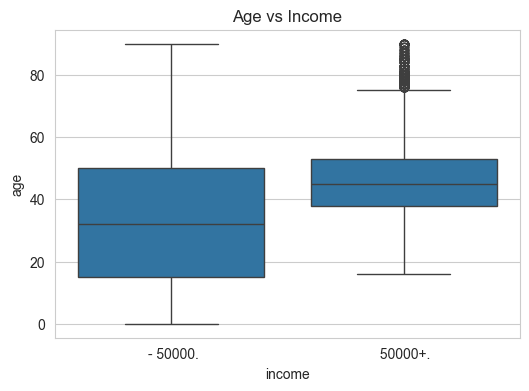

In [50]:
plt.figure(figsize=(6,4))
sns.boxplot(x="income", y="age", data=train_df)
plt.title("Age vs Income")
plt.show()



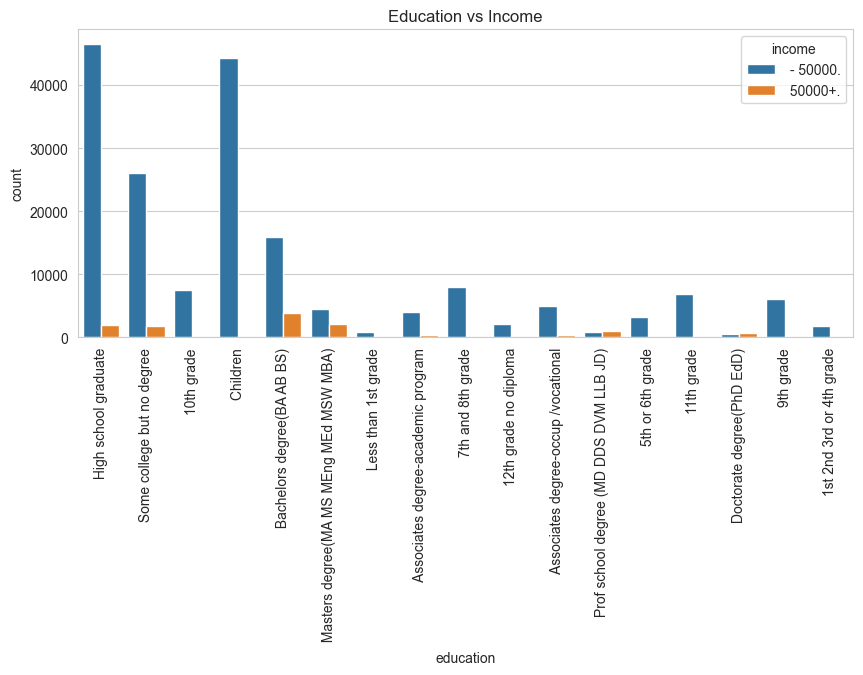

In [51]:
plt.figure(figsize=(10,4))
sns.countplot(x="education", hue="income", data=train_df)
plt.title("Education vs Income")
plt.xticks(rotation=90)
plt.show()

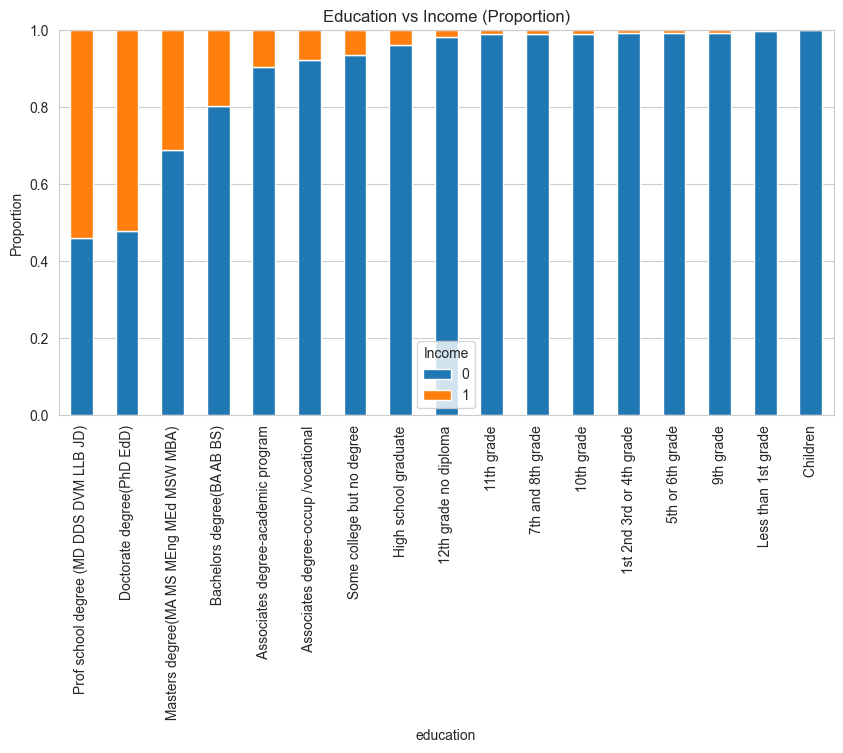

In [52]:
edu_income = (
    train_df
    .groupby("education")["income_enc"]
    .value_counts(normalize=True)
    .unstack()
)

# Sort by proportion of high income 
edu_income = edu_income.sort_values(by=1, ascending=False)

edu_income.plot(kind="bar", stacked=True, figsize=(10,5))

plt.title("Education vs Income (Proportion)")
plt.ylabel("Proportion")
plt.xticks(rotation=90)
plt.legend(title="Income")
plt.show()

### Education vs Income

- Higher education levels (Bachelors, Masters, Doctorate) show a higher income volume 
- Lower education levels are associated with lower income

### Modeling
- Education is a strong predictive feature
- Likely high feature importance in tree-based models


In [53]:
edu_counts = train_df["education"].value_counts()
top_edu = edu_counts[edu_counts > 1000].index

df_filtered = train_df[train_df["education"].isin(top_edu)]

In [54]:
order = (
    df_filtered
    .groupby("education")["age"]
    .median()
    .sort_values()
    .index
)



def group_education(x):
    if "Doctorate" in x or "Prof school" in x:
        return "Advanced"
    elif "Bachelors" in x or "Masters" in x:
        return "Degree"
    elif "Associates" in x:
        return "Mid"
    else:
        return "Low"

train_df["edu_group"] = train_df["education"].apply(group_education)

In [55]:
order = ["Low", "Mid", "Degree", "Advanced"]


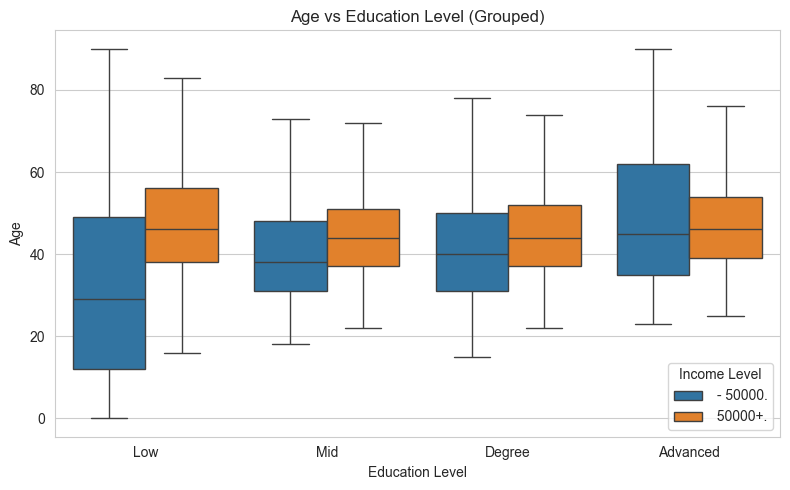

In [56]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x="edu_group",
    y="age",
    hue="income",
    data=train_df,
    order=order,
    showfliers=False
)

plt.title("Age vs Education Level (Grouped)")
plt.xlabel("Education Level")
plt.ylabel("Age")
plt.legend(title="Income Level")

plt.tight_layout()
plt.show()

# Age vs education levels 

- can see a clear trend in having low education makes for a higher percentage of low income bracket
- but a fairly even distribution of people having more than 50k , but the medians are higher for compared to those below 50k


In [57]:
train_df["capital_gains_log"] = np.log1p(train_df["capital gains"])

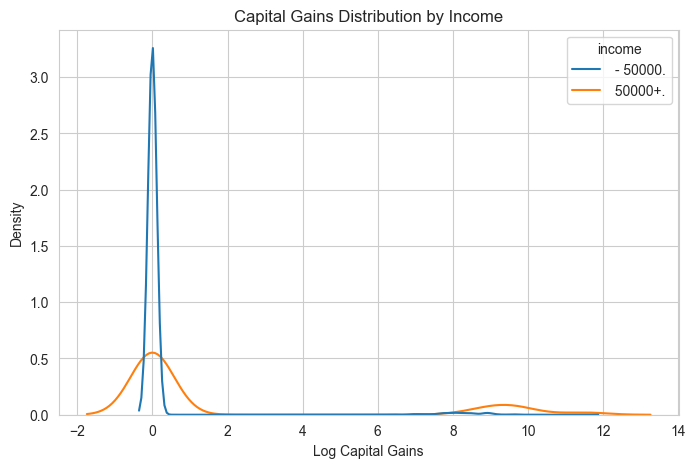

In [58]:
plt.figure(figsize=(8,5))

sns.kdeplot(
    data=train_df,
    x="capital_gains_log",
    hue="income",
    common_norm=False
)

plt.title("Capital Gains Distribution by Income")
plt.xlabel("Log Capital Gains")
plt.show()

### Capital Gains and Income

- Capital gains are heavily skewed, with most people were reporting zero values
- people with higher capital gains are more likely to belong to the above 50K bracket
- A clear separation exists between income groups after log transformation

### Modelling
- Capital gains is a high-signal feature
- Log transformation is required due to skewness
